# An initial training pipeline

In [ ]:
%load_ext dotenv
%dotenv 
import os
import sys
sys.path.append(os.getenv('SRC_DIR'))
import dask.dataframe as dd
import pandas as pd
import numpy as np

from glob import glob
ft_dir = os.getenv("FEATURES_DATA")
ft_glob = glob(ft_dir+'/*.parquet')
df = dd.read_parquet(ft_glob).compute().reset_index().dropna()


In [2]:
cat_file = os.path.join(
    os.getenv("PRICE_CSV_DATA"), 
    'symbols_valid_meta.csv'
)
cat_df = (pd.read_csv(cat_file)
          .rename(columns = {'Symbol': 'ticker'})[['ticker', 'Listing Exchange', 'Market Category']]
          )
df = df.merge(cat_df, on = 'ticker', how = 'left')

## Preprocessing

+ Previously, we produced a features data set.
+ Most times, one or more [preprocessing steps](https://scikit-learn.org/stable/modules/preprocessing.html#) steps will be applied to data.
+ The most practical way to apply them is by arranging them in `Pipeline` objects, wchich are sequential transformations applied to data. 
+ It is convenient for us to label these transformations and there is a standard way of doing so.


## Transformations

+ Transformations are classes that implement `fit` and `transform` methods.

### StandardScaler

+ For example, transform a numerical variable by standardizing it.
- Standardization is removing the mean value of the feature and scale it by dividing non-constant features by their standard deviation.

$$
z = \frac{x-\mu}{\sigma}
$$


+  Using [`StandardScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html), one can do the following:

In [3]:
df.columns

Index(['ticker', 'Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume',
       'source', 'Year', 'Close_lag_1', 'Listing Exchange', 'Market Category'],
      dtype='object')

In [4]:
df = (df.assign(
        returns = lambda x: x['Close']/x['Close_lag_1'] - 1, 
        positive_return = lambda x: 1.0*(x['returns'] > 0),
        hi_lo = lambda x: x['High'] - x['Low'],
        op_cl = lambda x: x['Close'] - x['Open']
    ).groupby(['ticker'], group_keys=False).apply(
        lambda x: x.assign(target = x['positive_return'].shift(-1))
    )
    .reset_index(drop=True)
    .dropna(subset = ['target'])
    )
df

/var/folders/51/mcycgk1j10v6n47l_1w_g1080000gn/T/ipykernel_11447/619560177.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = (df.assign(


,ticker,Date,Open,High,Low,Close,Adj Close,Volume,source,Year,Close_lag_1,Listing Exchange,Market Category,returns,positive_return,hi_lo,op_cl,target
0,A,1999-11-19,30.713520,30.758226,28.478184,28.880543,24.838577,15234100.0,A.csv,1999,31.473534,N,,-0.082386,0.0,2.280043,-1.832977,1.0
1,A,1999-11-22,29.551144,31.473534,28.657009,31.473534,27.068665,6577800.0,A.csv,1999,28.880543,N,,0.089783,1.0,2.816525,1.922390,0.0
2,A,1999-11-23,30.400572,31.205294,28.612303,28.612303,24.607880,5975600.0,A.csv,1999,31.473534,N,,-0.090909,0.0,2.592991,-1.788269,1.0
3,A,1999-11-24,28.701717,29.998211,28.612303,29.372318,25.261524,4843200.0,A.csv,1999,28.612303,N,,0.026563,1.0,1.385908,0.670601,1.0
4,A,1999-11-26,29.238197,29.685265,29.148785,29.461731,25.338428,1729400.0,A.csv,1999,29.372318,N,,0.003044,1.0,0.536480,0.223534,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
318478,ZEUS,2020-03-25,10.350000,10.500000,9.590000,9.670000,9.670000,48700.0,ZEUS.csv,2020,10.330000,Q,Q,-0.063892,0.0,0.910000,-0.680000,0.0
318479,ZEUS,2020-03-26,9.610000,9.940000,9.260000,9.590000,9.590000,60500.0,ZEUS.csv,2020,9.670000,Q,Q,-0.008273,0.0,0.679999,-0.020000,0.0
318480,ZEUS,2020-03-27,9.330000,9.330000,8.700000,8.700000,8.700000,52900.0,ZEUS.csv,2020,9.590000,Q,Q,-0.092805,0.0,0.630000,-0.630000,1.0
318481,ZEUS,2020-03-30,8.810000,9.760000,8.700000,9.680000,9.680000,73700.0,ZEUS.csv,2020,8.700000,Q,Q,0.112644,1.0,1.060000,0.870000,1.0


In [8]:
returns = df['returns'].values.reshape(-1, 1)
returns

array([[-0.08238639],
       [ 0.08978332],
       [-0.09090911],
       ...,
       [-0.09280504],
       [ 0.11264374],
       [ 0.06921488]])

In [9]:
# Create a StandardScaler object

from sklearn.preprocessing import StandardScaler
std_scaler = StandardScaler()


# Fit the StandardScaler object with the returns data
std_scaler.fit(returns)

StandardScaler()

In [11]:
std_scaler.mean_

array([0.64668508])

In [27]:
# Transform the returns data using the fitted scaler

scaled_returns_np = std_scaler.transform(returns)
scaled_returns = pd.DataFrame(scaled_returns_np, columns=['returns'])
scaled_returns.describe()

,returns
count,3.183950e+05
mean,-1.684888e-18
std,1.000002e+00
min,-6.170050e-03
25%,-2.466047e-03
50%,-2.423278e-03
75%,-2.381582e-03
max,5.585536e+02


###  OneHotEncoder

+ Categorical features can be encoded as numerical values using `OneHotEncoder`.

In [ ]:
# this is the origianl statistical 
df.returns.describe()

count    318395.000000
mean          0.646685
std         266.864234
min          -0.999878
25%          -0.011414
50%           0.000000
75%           0.011127
max      149058.378332
Name: returns, dtype: float64

<Axes: xlabel='Listing Exchange'>

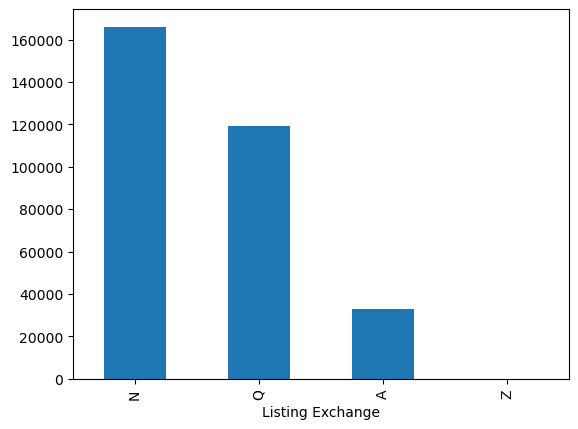

In [13]:
df['Listing Exchange'].value_counts().plot(kind = 'bar')

+ Use [`OneHotEncoder`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) to encode a categorical variable as numerical.
+ Important parameters:

    - `categories` allows you to specify the categories to work with.
    - `drop`: we can drop the `'first'` value (dummy encoding) or `'if_binary'`, a convenience setting for binary values.
    - `handle_unknown` allows three options, `'error'`, `'ignore'`, and `'infrequent_if_exist'`, depending on what we want to do with new values.

In [16]:
from sklearn.preprocessing import OneHotEncoder
onehot = OneHotEncoder(drop='first')
onehot.fit(df[['Listing Exchange']])

OneHotEncoder(drop='first')

In [17]:
listing_enc = onehot.transform(df[['Listing Exchange']])
listing_enc.toarray()

array([[1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       ...,
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.]])

# Pipelines

+ It is impractical and costly to manipulate data "by hand". 
+ To manage data preprocessing steps within the cross-validation process use `Pipeline` objects.
+ A [`Pipeline`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html) object allows us to sequentially apply transformation steps and, if required, a predictor.
+ `Pipeline` objects compose transforms, i.e., classes that implement `transform` and `fit` methods.
+ The purpose of `Pipeline` objects is to ensemble transforms and predictors to be used in cross-validation.
+ A `Pipeline` is defined by a list of tuples.
+ Each tuple is composed of `("name", <ColumnTransformer>)`, the name of the step and the `<ColumnTransformer>` function of our chosing.

In [18]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, log_loss, cohen_kappa_score, f1_score


In [19]:
pipe1 = Pipeline(
    [
        ('onehot', OneHotEncoder(handle_unknown='ignore')),
        ('knn', DecisionTreeClassifier(criterion = 'entropy', max_depth=3))

    ]
)
pipe1

Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore')),
                ('knn',
                 DecisionTreeClassifier(criterion='entropy', max_depth=3))])

In [20]:
X0 = df[['Listing Exchange', 'Market Category']]
Y0 = df['target']
X0_train, X0_test, Y0_train, Y0_test = train_test_split(X0, Y0, test_size=0.2, random_state=42)

pipe1.fit(X0_train, Y0_train)

Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore')),
                ('knn',
                 DecisionTreeClassifier(criterion='entropy', max_depth=3))])

In [21]:
Y_pred_train = pipe1.predict(X0_train)
Y_pred_test = pipe1.predict(X0_test)

In [22]:
Y_poba_train = pipe1.predict_proba(X0_train)
Y_proba_test = pipe1.predict_proba(X0_test)

In [30]:
Y_pred_train

array([0., 0., 0., ..., 0., 0., 0.])

In [29]:
Y_poba_train

array([[0.63431254, 0.36568746],
       [0.53662066, 0.46337934],
       [0.53662066, 0.46337934],
       ...,
       [0.53662066, 0.46337934],
       [0.53662066, 0.46337934],
       [0.53662066, 0.46337934]])

In [23]:
res = {
    'accuracy_score_train': accuracy_score(Y0_train, Y_pred_train),
    'accuracy_score_test': accuracy_score(Y0_test, Y_pred_test),
    'cohen_kappa_train': cohen_kappa_score(Y0_train, Y_pred_train),
    'cohen_kappa_test': cohen_kappa_score(Y0_test, Y_pred_test),
    'log_loss_train': log_loss(Y0_train, Y_poba_train),
    'log_loss_test': log_loss(Y0_test, Y_proba_test),
    'f1_score_train': f1_score(Y0_train, Y_pred_train),
    'f1_score_test': f1_score(Y0_test, Y_pred_test)
}
res

{'accuracy_score_train': 0.5592306725922204,
 'accuracy_score_test': 0.5547982851489502,
 'cohen_kappa_train': 0.0,
 'cohen_kappa_test': 0.0,
 'log_loss_train': 0.6830030037058866,
 'log_loss_test': 0.6840710152822322,
 'f1_score_train': 0.0,
 'f1_score_test': 0.0}

+ The model does not show great performance, but the pipeline shows results. 
+ Below, we expand the pipeline to include more variables, and further we will work with more robust model selection pipelines.

## ColumnTransformer

+ Use [`ColumnTransformer`](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html) to apply transformers to specific columns of a DataFrame.
+ In this case, we will scale numeric variables and apply one-hot encoding to categorical columns.

In [24]:
from sklearn.compose import ColumnTransformer

In [ ]:
transformer = ColumnTransformer(
    transformers=[
        ('numeric_transfomer', StandardScaler(), ['returns', 'Volume', 'op_cl', 'hi_lo'] ),
        ('onehot', OneHotEncoder(handle_unknown='infrequent_if_exist'), ['Listing Exchange', 'Market Category']), 
    ], remainder='drop' # another option can be passthrough
)

pipe = Pipeline(
    [
        ('preproc', transformer), 
        ('decisiontree', DecisionTreeClassifier(criterion = 'entropy', max_depth=3))
    ]
)

In [31]:
pipe

Pipeline(steps=[('preproc',
                 ColumnTransformer(transformers=[('numeric_transfomer',
                                                  StandardScaler(),
                                                  ['returns', 'Volume', 'op_cl',
                                                   'hi_lo']),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='infrequent_if_exist'),
                                                  ['Listing Exchange',
                                                   'Market Category'])])),
                ('decisiontree',
                 DecisionTreeClassifier(criterion='entropy', max_depth=3))])

# Model Selection

The model selection process is an iterative process in which :

+ Select schema and load data.
+ Define a pipeline and its (hyper) parameters.

    - Use ColumnTransformers to transform numeric and cateogrical variables.
    - Hyperparameters can be defined independently of code. 

+ Implement a splitting strategy. 

    - Use [cross_validate]() to select several metrics and operational details.

+ Measure performance.

    - [Select metrics](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.metrics)

+ Repeat

## Training, Validation, Testing Split

+ The first spliting strategy is to use a training, validation, and test set.
+ Training set will be used to fit the model.
+ Validation set is used to evaluate hyperparameter choice.
+ Testing set is used to evaluate performance on data the model has not yet seen.
+ In this case we want to compare two models: 

    - Decision Tree with 3 minumum samples per leaf.
    - Decision Tree with 10 minimum samples per leaf.

![](./images/03b_train_validate_test.png)

## Setting parameters in pipeline steps

+ One can obtain the parameters of a pipeline with `pipe.get_params()`.
+ We can set any parameter of a pipeline with `pipe.set_parames(**kwargs)`. 
+ The input `**kwargs` is a dictionary of the params to be modified. Params of the steps are labeled with the name of the step followed by `__` and the name of the parameter.

+ There are a few steps that we will repeat: 

    - Fit the candidate model on training data.
    - Predict on training and test data.
    - Compute training and test performance metrics.
    - Return.

+ We encapsulate this procedure in a function. 

In [32]:
def evaluate_model(clf, X_train, Y_train, X_test, Y_test):
    clf.fit(X_train, Y_train)
    Y_pred_train = clf.predict(X_train)
    Y_pred_test = clf.predict(X_test)
    Y_proba_train = clf.predict_proba(X_train)
    Y_proba_test = clf.predict_proba(X_test)
    performance_metrics = {
        'log_loss_train': log_loss(Y_train, Y_proba_train),
        'log_loss_test': log_loss(Y_test, Y_proba_test),
        'cohen_kappa_train': cohen_kappa_score(Y_train, Y_pred_train),
        'cohen_kappa_test': cohen_kappa_score(Y_test, Y_pred_test),
        'f1_score_train': f1_score(Y_train, Y_pred_train),
        'f1_score_test': f1_score(Y_test, Y_pred_test),
        'accuracy_score_train': accuracy_score(Y_train, Y_pred_train),
        'accuracy_score_test': accuracy_score(Y_test, Y_pred_test),
    }
    return performance_metrics

In [33]:
# Schema
X = df[['returns', 'op_cl', 'hi_lo', 'Volume', 'Listing Exchange', 'Market Category']]
Y = df['target']

# Split the data
X_rest, X_test, Y_rest, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
X_train, X_validate, Y_train,  Y_validate = train_test_split(X_rest, Y_rest, test_size=0.2, random_state=42)


In [34]:
# Evaluate hyperparameter configuration 2
pipe_d3 = pipe.set_params(**{'decisiontree__max_depth': 3})
res_d3 = evaluate_model(pipe_d3, X_train, Y_train, X_validate, Y_validate)
res_d3

{'log_loss_train': 0.6723565140659331,
 'log_loss_test': 0.6723389280423615,
 'cohen_kappa_train': 0.0013111302600298247,
 'cohen_kappa_test': 0.0013098011744396842,
 'f1_score_train': 0.003286697757050855,
 'f1_score_test': 0.0033828896999910977,
 'accuracy_score_train': 0.5594880552774669,
 'accuracy_score_test': 0.5604978015075377}

In [36]:
pipe.get_params()

{'memory': None,
 'steps': [('preproc',
   ColumnTransformer(transformers=[('numeric_transfomer', StandardScaler(),
                                    ['returns', 'Volume', 'op_cl', 'hi_lo']),
                                   ('onehot',
                                    OneHotEncoder(handle_unknown='infrequent_if_exist'),
                                    ['Listing Exchange', 'Market Category'])])),
  ('decisiontree', DecisionTreeClassifier(criterion='entropy', max_depth=15))],
 'verbose': False,
 'preproc': ColumnTransformer(transformers=[('numeric_transfomer', StandardScaler(),
                                  ['returns', 'Volume', 'op_cl', 'hi_lo']),
                                 ('onehot',
                                  OneHotEncoder(handle_unknown='infrequent_if_exist'),
                                  ['Listing Exchange', 'Market Category'])]),
 'decisiontree': DecisionTreeClassifier(criterion='entropy', max_depth=15),
 'preproc__force_int_remainder_cols': True,
 

In [ ]:
# Evaluate hyperparameter configuration 2
# in python ** autotranslate to: decisiontree__max_depth=15
pipe_d15 = pipe.set_params(**{'decisiontree__max_depth':15})
res_d15 = evaluate_model(pipe_d15, X_train, Y_train, X_validate, Y_validate)
res_d15

{'log_loss_train': 0.6318209333356377,
 'log_loss_test': 1.3722175434918515,
 'cohen_kappa_train': 0.14992944491957194,
 'cohen_kappa_test': 0.07457100835046082,
 'f1_score_train': 0.48332375461169097,
 'f1_score_test': 0.43774872086412736,
 'accuracy_score_train': 0.5897031976915376,
 'accuracy_score_test': 0.5534901067839196}

## Cross-Validation

+ Cross-validation is a resampling method.
+ It is an iterative method applied to training data.
+ Training data is divided into folds.
+ Each fold is used once as a validation set and the rest of the folds are used for training.
+ Test data is used for final evaluation.

From [Scikit's Documentation ](https://scikit-learn.org/stable/modules/cross_validation.html#cross-validation-evaluating-estimator-performance), the diagram below shows the data divisions and folds during the cross-validation process.

![](./images/03b_grid_search_cross_validation.png)

There are two functions that can be used for [calculating cross-validation performance scores](https://scikit-learn.org/stable/modules/cross_validation.html#cross-validation-evaluating-estimator-performance): `cross_val_score()` and `cross_validate()`. The first function, [`cross_val_score()`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html#sklearn.model_selection.cross_val_score), is a convenience function to get quick perfromance calculations. We will discuss `cross_validate()` as it offers advantages over `cross_val_score()`.

## Obtaining metrics

+ Use [`cross_validate`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html#sklearn.model_selection.cross_validate) to measure one or more performance metrics and operational details.
+ There are two advantages of using this function. From [Scikit's documentation](https://scikit-learn.org/stable/modules/cross_validation.html#the-cross-validate-function-and-multiple-metric-evaluation):

>- It allows specifying multiple metrics for evaluation.
>- It returns a dict containing fit-times, score-times (and optionally training scores, fitted estimators, train-test split indices) in addition to the test score.


In [37]:
from sklearn.model_selection import cross_validate
scoring = ['accuracy', 'f1', 'precision', 'recall', 'roc_auc', 'neg_log_loss', 'neg_brier_score']
d3_dict = cross_validate(pipe_d3, X, Y, cv=5, scoring = scoring, return_train_score = True)

In DataFrame form:

In [38]:
pd.DataFrame(d3_dict)

,fit_time,score_time,test_accuracy,train_accuracy,test_f1,train_f1,test_precision,train_precision,test_recall,train_recall,test_roc_auc,train_roc_auc,test_neg_log_loss,train_neg_log_loss,test_neg_brier_score,train_neg_brier_score
0,6.373886,0.873170,0.536802,0.596555,0.477670,0.484070,0.475816,0.556134,0.479538,0.428540,0.541238,0.648177,-3.462061,-0.628937,-0.286572,-0.223497
1,6.538995,0.600915,0.550401,0.595275,0.370963,0.485892,0.485451,0.553434,0.300171,0.433043,0.564999,0.644641,-1.561183,-0.630854,-0.255288,-0.224394
2,6.532692,0.966988,0.523375,0.597587,0.323112,0.390307,0.433383,0.589857,0.257574,0.291643,0.511398,0.652708,-2.111021,-0.625740,-0.278609,-0.222183
3,7.327705,0.923849,0.541120,0.597909,0.437722,0.478383,0.476997,0.560094,0.404423,0.417478,0.547864,0.647624,-1.530379,-0.630873,-0.261317,-0.224226
4,7.168166,0.870130,0.544874,0.590198,0.384043,0.487240,0.477335,0.544546,0.321256,0.440847,0.559366,0.638741,-1.972888,-0.633398,-0.260650,-0.225393


In [39]:
d15_dict = cross_validate(pipe_d15, X, Y, cv=5, scoring = scoring, return_train_score = True)
pd.DataFrame(d15_dict)

,fit_time,score_time,test_accuracy,train_accuracy,test_f1,train_f1,test_precision,train_precision,test_recall,train_recall,test_roc_auc,train_roc_auc,test_neg_log_loss,train_neg_log_loss,test_neg_brier_score,train_neg_brier_score
0,6.246487,0.622525,0.536849,0.596507,0.478268,0.484439,0.475919,0.555957,0.480640,0.429224,0.541736,0.648177,-3.446842,-0.628885,-0.286344,-0.223477
1,7.886802,1.050029,0.550181,0.595235,0.369852,0.485647,0.484999,0.553423,0.298891,0.432660,0.564922,0.644561,-1.561773,-0.630896,-0.255303,-0.224412
2,9.147659,1.229654,0.524066,0.597575,0.324725,0.390329,0.434863,0.589812,0.259103,0.291679,0.512942,0.652694,-2.079546,-0.625825,-0.277807,-0.222204
3,6.549060,0.974063,0.541230,0.597972,0.438084,0.478783,0.477164,0.560103,0.404921,0.418082,0.548201,0.647745,-1.525634,-0.630842,-0.261258,-0.224209
4,7.213023,0.650914,0.546884,0.590253,0.383567,0.487364,0.480465,0.544612,0.319194,0.441007,0.562640,0.638827,-1.897245,-0.633372,-0.258610,-0.225379


# About Performance

+ Notice that in order to acquire information about our model and continue development, we are spending resources: time, electricity, equipment use, etc. As well, we are generating data and binary objects that implement our models (fitted `Pipeline` objects, for example).
+ For certain applications, operating performance (latency or `'score_time'`) may be as important or more important than predictive performance metrics. 
+ Every experiment throws important information and we can log them, as well as run them systematically.

In [40]:
pd.DataFrame(d15_dict).mean()

fit_time                 7.408606
score_time               0.905437
test_accuracy            0.539842
train_accuracy           0.595509
test_f1                  0.398899
train_f1                 0.465313
test_precision           0.470682
train_precision          0.560782
test_recall              0.352550
train_recall             0.402531
test_roc_auc             0.546088
train_roc_auc            0.646401
test_neg_log_loss       -2.102208
train_neg_log_loss      -0.629964
test_neg_brier_score    -0.267864
train_neg_brier_score   -0.223936
dtype: float64